# CNN for Classification: Cats vs. Dogs
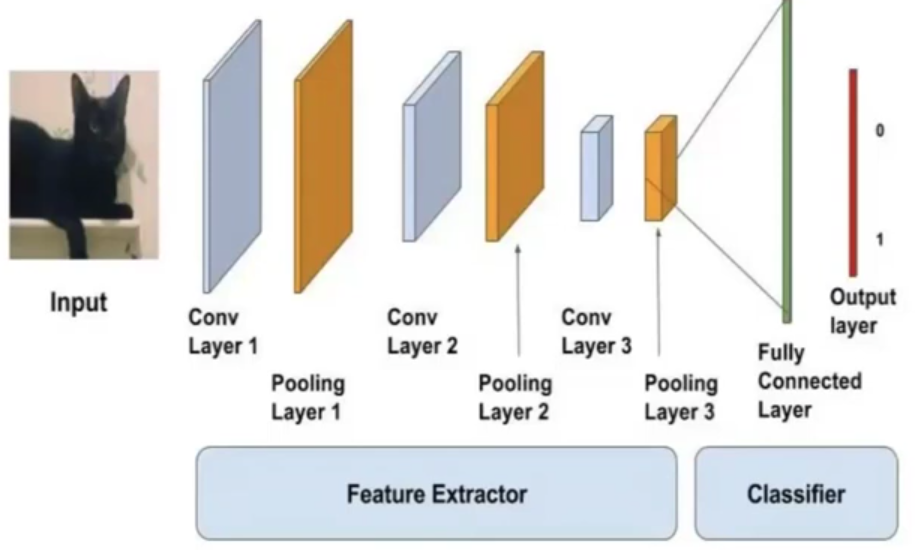

dataset source: https://www.microsoft.com/en-us/download/details.aspx?id=54765

In [1]:
import os
from pathlib import Path
import requests
import zipfile
import shutil
import random

In [2]:
# Dataset URL

url = "https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip"

# Dataset on Kaggle: https://www.kaggle.com/c/dogs-vs-cats/data

# Define paths relative to the notebook location
notebook_dir = Path("/home/serhii/Documents/DataScience/DSLectures/DataScience_sandbox/notebooks/module10")
data_dir = notebook_dir.parent.parent / "data" / "cats_vs_dogs"

print(f"Checking paths:")
print(f"Data directory: {data_dir}")
print(f"Train path: {data_dir / 'train'}")
print(f"Validation path: {data_dir / 'validation'}")
print(f"Test path: {data_dir / 'test'}")

Checking paths:
Data directory: /home/serhii/Documents/DataScience/DSLectures/DataScience_sandbox/data/cats_vs_dogs
Train path: /home/serhii/Documents/DataScience/DSLectures/DataScience_sandbox/data/cats_vs_dogs/train
Validation path: /home/serhii/Documents/DataScience/DSLectures/DataScience_sandbox/data/cats_vs_dogs/validation
Test path: /home/serhii/Documents/DataScience/DSLectures/DataScience_sandbox/data/cats_vs_dogs/test


In [3]:
# Check if train/validation/test directories exist and contain jpg files
def check_data_exists():
    """Check if train/validation/test folders contain jpg files"""
    splits = ["train", "validation", "test"]
    classes = ["cats", "dogs"]
    
    data_ready = True
    
    for split in splits:
        split_path = data_dir / split
        if not split_path.exists():
            print(f"{split} directory does not exist")
            data_ready = False
            continue
            
        for class_name in classes:
            class_path = split_path / class_name
            if class_path.exists():
                jpg_files = list(class_path.glob("*.jpg"))
                count = len(jpg_files)
                print(f"{split}/{class_name}: {count} jpg files")
                if count == 0:
                    data_ready = False
            else:
                print(f"{split}/{class_name} directory does not exist")
                data_ready = False
    
    return data_ready

data_ready = check_data_exists()
print(f"\nData is ready: {data_ready}")

train/cats: 8723 jpg files
train/dogs: 8723 jpg files
validation/cats: 2489 jpg files
validation/dogs: 2486 jpg files
test/cats: 1246 jpg files
test/dogs: 1245 jpg files

Data is ready: True


In [4]:
# Data Splitting into Train/Validation/Test sets
import random
import shutil
from pathlib import Path

# Create the split directories
def create_split_directories(base_dir: Path) -> None:
    """Create train/validation/test directories with cats/dogs subdirectories"""
    print("Creating dataset split directories...")
    
    splits = ["train", "validation", "test"]
    classes = ["cats", "dogs"]
    
    for split in splits:
        split_dir = base_dir / split
        split_dir.mkdir(exist_ok=True)
        for class_name in classes:
            class_dir = split_dir / class_name
            class_dir.mkdir(exist_ok=True)
    
    print("Directory structure created successfully")

# Split and copy files
def split_and_copy_data(cat_source: Path, dog_source: Path, base_dir: Path,
                       train_ratio: float = 0.7, val_ratio: float = 0.2) -> None:
    """
    Split the data into train/validation/test sets and copy files

    Args:
        cat_source: Path to Cat directory
        dog_source: Path to Dog directory
        base_dir: Base directory for splits
        train_ratio: Ratio of training data (default 0.7)
        val_ratio: Ratio of validation data (default 0.2)
        test_ratio will be 1 - train_ratio - val_ratio
    """
    print("Splitting and copying data...")

    # Get all image files
    cat_files = list(cat_source.glob("*.jpg"))
    dog_files = list(dog_source.glob("*.jpg"))

    print(f"Found {len(cat_files)} cat images and {len(dog_files)} dog images")

    # Shuffle the files
    random.seed(42)  # For reproducibility
    random.shuffle(cat_files)
    random.shuffle(dog_files)

    # Calculate split indices
    def get_split_indices(total_files, train_ratio, val_ratio):
        train_end = int(total_files * train_ratio)
        val_end = int(total_files * (train_ratio + val_ratio))
        return train_end, val_end

    cat_train_end, cat_val_end = get_split_indices(len(cat_files), train_ratio, val_ratio)
    dog_train_end, dog_val_end = get_split_indices(len(dog_files), train_ratio, val_ratio)

    # Define splits
    splits_data = {
        'train': {
            'cats': cat_files[:cat_train_end],
            'dogs': dog_files[:dog_train_end]
        },
        'validation': {
            'cats': cat_files[cat_train_end:cat_val_end],
            'dogs': dog_files[dog_train_end:dog_val_end]
        },
        'test': {
            'cats': cat_files[cat_val_end:],
            'dogs': dog_files[dog_val_end:]
        }
    }

    # Copy files to respective directories
    for split_name, split_data in splits_data.items():
        print(f"\nCopying {split_name} data...")

        for class_name, files in split_data.items():
            dest_dir = base_dir / split_name / class_name
            print(f"  Copying {len(files)} {class_name} images to {split_name}/{class_name}")

            for i, src_file in enumerate(files):
                # Create new filename with class prefix
                new_filename = f"{class_name}_{i+1}.jpg"
                dest_file = dest_dir / new_filename
                shutil.copy2(src_file, dest_file)

    print("\nData splitting completed!")


In [5]:
# Download, extract and split dataset if needed
if not data_ready:
    print("Downloading cats vs dogs dataset...")
    
    # Create data directory if it doesn't exist
    data_dir.mkdir(parents=True, exist_ok=True)
    
    # Download the zip file
    zip_path = data_dir / "kagglecatsanddogs_5340.zip"
    
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))
    
    with open(zip_path, 'wb') as f:
        downloaded = 0
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
                downloaded += len(chunk)
                if total_size:
                    percent = (downloaded / total_size) * 100
                    print(f"Downloaded: {percent:.1f}%", end='\r')
    
    print(f"\nDownload complete: {zip_path}")
    
    # Extract and split data immediately
    extract_dir = data_dir / "extracted"
    
    # Extract the zip file
    print("Extracting archive...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction complete")
    
    # Find Cat and Dog folders in extracted archive
    source_cat = None
    source_dog = None
    
    # Search for Cat and Dog directories
    for root, dirs, files in os.walk(extract_dir):
        for directory in dirs:
            if directory == "Cat" and source_cat is None:
                source_cat = Path(root) / "Cat"
                print(f"Found Cat at: {source_cat}")
            if directory == "Dog" and source_dog is None:
                source_dog = Path(root) / "Dog"
                print(f"Found Dog at: {source_dog}")
    
    # Create split directories
    create_split_directories(data_dir)
    
    # Split and copy data directly to train/validation/test
    if source_cat and source_cat.exists() and source_dog and source_dog.exists():
        split_and_copy_data(source_cat, source_dog, data_dir)
    else:
        print("Error: Could not find Cat and Dog folders in the archive")
    
    # Clean up - remove archive and extracted folder
    print("\nCleaning up temporary files...")
    if zip_path.exists():
        os.remove(zip_path)
        print(f"Removed: {zip_path}")
    
    if extract_dir.exists():
        shutil.rmtree(extract_dir)
        print(f"Removed: {extract_dir}")
    
    print("Cleanup complete")
    
    # Verify the data
    print("\nVerifying data...")
    check_data_exists()
else:
    print("Dataset already exists, skipping download and processing")

Dataset already exists, skipping download and processing


In [6]:
# Summary - Count the files in each split
print("="*60)
print("FINAL DATASET SUMMARY:")
print("="*60)

splits = ["train", "validation", "test"]
classes = ["cats", "dogs"]

total_images = 0
for split in splits:
    print(f"\n{split.upper()}:")
    split_total = 0
    for class_name in classes:
        class_dir = data_dir / split / class_name
        if class_dir.exists():
            count = len(list(class_dir.glob("*.jpg")))
            print(f"  {class_name}: {count} images")
            split_total += count
        else:
            print(f"  {class_name}: directory not found")
    print(f"  Total: {split_total} images")
    total_images += split_total

print(f"\n{'='*60}")
print(f"GRAND TOTAL: {total_images} images")
print(f"Dataset location: {data_dir}")
print("="*60)

FINAL DATASET SUMMARY:

TRAIN:
  cats: 8723 images
  dogs: 8723 images
  Total: 17446 images

VALIDATION:
  cats: 2489 images
  dogs: 2486 images
  Total: 4975 images

TEST:
  cats: 1246 images
  dogs: 1245 images
  Total: 2491 images

GRAND TOTAL: 24912 images
Dataset location: /home/serhii/Documents/DataScience/DSLectures/DataScience_sandbox/data/cats_vs_dogs


In [7]:
#import re
#fnames_cats = [f for f in os.listdir(path+"/Cat") if re.match(r'[0-9]+.*\.jpg', f)]
#fnames_dogs = [f for f in os.listdir(path+"/Dog") if re.match(r'[0-9]+.*\.jpg', f)]

In [8]:
# Check and clean image files in all dataset directories
import re
from pathlib import Path
import imghdr
import os
import time
from PIL import Image

# Define image validation function
def extract_corrupt_img_files(dir_path):
    """
    Gets corrupted image files within a directory and removes them
    Also checks for proper number of channels (must be 3 for RGB)

    Arguments:
    dir_path: a string representing the path for the target directory

    Returns:
    a list of the path for the corrupted image files
    """
    if not os.path.exists(dir_path):
        print(f"Directory {dir_path} does not exist, skipping...")
        return []

    i = 0
    beg = time.time()
    corrupted = []
    invalid_channels = []
    try:
        files = os.listdir(dir_path)
    except OSError as e:
        print(f"Error accessing directory {dir_path}: {e}")
        return []

    for filename in files:
        i += 1
        if (i % 50 == 0):
            print(i, end=" ")
        if (i % 1000 == 0):
            print()

        filepath = os.path.join(dir_path, filename)
        try:
            img = Image.open(filepath)
            img.verify()  # Verify the image is not corrupted
            
            # Reopen image to check channels (verify() closes the image)
            img = Image.open(filepath)
            
            # Check if image has 3 channels (RGB)
            if img.mode not in ['RGB', 'RGBA', 'L']:
                invalid_channels.append(filename)
                print(f"Removed image with {img.mode} color mode (not RGB): {filename}")
                try:
                    os.remove(filepath)
                except OSError:
                    print(f"Could not remove: {filename}")
            elif img.mode == 'L':  # Grayscale
                # Convert grayscale to RGB
                rgb_img = img.convert('RGB')
                rgb_img.save(filepath, 'JPEG')
                print(f"Converted grayscale to RGB: {filename}")
            elif img.mode == 'RGBA':  # RGBA
                # Convert RGBA to RGB
                rgb_img = img.convert('RGB')
                rgb_img.save(filepath, 'JPEG')
                print(f"Converted RGBA to RGB: {filename}")
                
        except Exception as e:
            corrupted.append(filename)
            try:
                os.remove(filepath)
                print(f"Removed corrupted file: {filename}")
            except OSError:
                print(f"Could not remove corrupted file: {filename}")
            continue

    end = time.time()
    print()
    print('*'*50)
    print(f"\nTask finished in {end-beg:.2f} seconds")
    print(f"{len(corrupted)} corrupted files found and removed")
    print(f"{len(invalid_channels)} files with invalid color modes removed/converted")
    print(f"Total removed/fixed: {len(corrupted) + len(invalid_channels)}")
    print('*'*50)
    return corrupted + invalid_channels

# Check for non-standard image formats
def check_image_formats(dir_path):
    """
    Check for image files that are not in accepted formats for TensorFlow
    """
    if not os.path.exists(dir_path):
        print(f"Directory {dir_path} does not exist, skipping...")
        return

    image_extensions = [".png", ".jpg", ".jpeg", ".bmp", ".gif"]
    img_type_accepted_by_tf = ["bmp", "gif", "jpeg", "png"]

    removed_count = 0
    for filepath in Path(dir_path).rglob("*"):
        if filepath.suffix.lower() in image_extensions:
            img_type = imghdr.what(str(filepath))
            if img_type is None:
                print(f"{filepath} is not an image and will be removed")
                try:
                    os.remove(filepath)
                    removed_count += 1
                except OSError:
                    print(f"Could not remove: {filepath}")
            elif img_type not in img_type_accepted_by_tf:
                print(f"{filepath} is a {img_type}, not accepted by TensorFlow and will be removed")
                try:
                    os.remove(filepath)
                    removed_count += 1
                except OSError:
                    print(f"Could not remove: {filepath}")

    if removed_count > 0:
        print(f"Removed {removed_count} files with unsupported formats from {dir_path}")

# Clean all dataset directories
print("Starting data cleaning process...")
print("="*60)

splits = ["train", "validation", "test"]
classes = ["cats", "dogs"]

total_cleaned = 0

for split in splits:
    for class_name in classes:
        dir_path = data_dir / split / class_name
        print(f"\nCleaning {split}/{class_name}...")

        # Check for corrupted images
        corrupted = extract_corrupt_img_files(str(dir_path))
        total_cleaned += len(corrupted)

        # Check for unsupported formats
        check_image_formats(dir_path)

print(f"\n{'='*60}")
print(f"Data cleaning completed! Total files removed: {total_cleaned}")
print("="*60)

# Final verification
print("\nFinal dataset verification:")
check_data_exists()

Starting data cleaning process...

Cleaning train/cats...
50 100 150 200 250 300 350 400 450 500 550 600 650 700 750 800 850 900 950 1000 
1050 1100 1150 1200 1250 1300 1350 1400 1450 1500 1550 1600 1650 1700 1750 1800 1850 1900 1950 2000 
2050 2100 2150 2200 2250 2300 2350 2400 2450 2500 2550 2600 2650 2700 2750 2800 2850 2900 2950 3000 
3050 3100 3150 3200 

/tmp/ipykernel_138761/2924265202.py:4: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


3250 3300 3350 3400 3450 3500 3550 3600 3650 3700 3750 3800 3850 3900 3950 4000 
4050 4100 4150 4200 4250 4300 4350 4400 4450 4500 4550 4600 4650 4700 4750 4800 4850 4900 4950 5000 
5050 5100 5150 5200 5250 5300 5350 5400 5450 5500 5550 5600 5650 5700 5750 5800 5850 5900 5950 6000 
6050 6100 6150 6200 6250 6300 6350 6400 6450 6500 6550 6600 6650 6700 6750 6800 6850 6900 6950 7000 
7050 7100 7150 7200 7250 7300 7350 7400 7450 7500 7550 7600 7650 7700 7750 7800 7850 7900 7950 8000 
8050 8100 8150 8200 8250 8300 8350 8400 8450 8500 8550 8600 8650 8700 
**************************************************

Task finished in 0.38 seconds
0 corrupted files found and removed
0 files with invalid color modes removed/converted
Total removed/fixed: 0
**************************************************

Cleaning train/dogs...
50 100 150 200 250 300 350 400 450 500 550 600 650 700 750 800 850 900 950 1000 
1050 1100 1150 1200 1250 1300 1350 1400 1450 1500 1550 1600 1650 1700 1750 1800 1850 1900 1950 2

/home/serhii/Documents/DataScience/DSLectures/DataScience_sandbox/.ds_lect_env/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


850 900 950 1000 
1050 1100 1150 1200 1250 1300 1350 1400 1450 1500 1550 1600 1650 1700 1750 1800 1850 1900 1950 2000 
2050 2100 2150 2200 2250 2300 2350 2400 2450 
**************************************************

Task finished in 0.11 seconds
0 corrupted files found and removed
0 files with invalid color modes removed/converted
Total removed/fixed: 0
**************************************************

Cleaning validation/dogs...
50 100 150 200 250 300 350 400 450 500 550 600 650 700 750 800 850 900 950 1000 
1050 1100 1150 1200 1250 1300 1350 1400 1450 1500 1550 1600 1650 1700 1750 1800 1850 1900 1950 2000 
2050 2100 2150 2200 2250 2300 2350 2400 2450 
**************************************************

Task finished in 0.11 seconds
0 corrupted files found and removed
0 files with invalid color modes removed/converted
Total removed/fixed: 0
**************************************************

Cleaning test/cats...
50 100 150 200 250 300 350 400 450 500 550 600 650 700 750 800 850 90

True

In [9]:
# Re-run data cleaning with updated function (checks color channels)
print("Re-running data cleaning with channel validation...")
print("="*60)

splits = ["train", "validation", "test"]
classes = ["cats", "dogs"]

total_cleaned = 0

for split in splits:
    for class_name in classes:
        dir_path = data_dir / split / class_name
        print(f"\nCleaning {split}/{class_name}...")

        # Check for corrupted images and invalid channels
        cleaned = extract_corrupt_img_files(str(dir_path))
        total_cleaned += len(cleaned)

print(f"\n{'='*60}")
print(f"Data cleaning completed! Total files removed/fixed: {total_cleaned}")
print("="*60)

# Final verification
print("\nFinal dataset verification:")
check_data_exists()

Re-running data cleaning with channel validation...

Cleaning train/cats...
50 100 150 200 250 300 350 400 450 500 550 600 650 700 750 800 850 900 950 1000 
1050 1100 1150 1200 1250 1300 1350 1400 1450 1500 1550 1600 1650 1700 1750 1800 1850 1900 1950 2000 
2050 2100 2150 2200 2250 2300 2350 2400 2450 2500 2550 2600 2650 2700 2750 2800 2850 2900 2950 3000 
3050 3100 3150 3200 3250 3300 3350 3400 3450 3500 3550 3600 3650 3700 3750 3800 3850 3900 3950 4000 
4050 4100 4150 4200 4250 4300 4350 4400 4450 4500 4550 4600 4650 4700 4750 4800 4850 4900 4950 5000 
5050 5100 5150 5200 5250 5300 5350 5400 5450 5500 5550 5600 5650 5700 5750 5800 5850 5900 5950 6000 
6050 6100 6150 6200 6250 6300 6350 6400 6450 6500 6550 6600 6650 6700 6750 6800 6850 6900 6950 7000 
7050 7100 7150 7200 7250 7300 7350 7400 7450 7500 7550 7600 7650 7700 7750 7800 7850 7900 7950 8000 
8050 8100 8150 8200 8250 8300 8350 8400 8450 8500 8550 8600 8650 8700 
**************************************************

Task finished

True

In [36]:
# Additional Data Cleaning Method 1: Check for non-standard image formats using imghdr
from pathlib import Path
import imghdr

print("Method 1: Checking for non-standard image formats...")
print("="*60)

splits = ["train", "validation", "test"]
classes = ["cats", "dogs"]
image_extensions = [".png", ".jpg", ".jpeg", ".bmp", ".gif"]
img_type_accepted_by_tf = ["bmp", "gif", "jpeg", "png"]

total_removed_method1 = 0

for split in splits:
    for class_name in classes:
        data_dir_path = data_dir / split / class_name
        print(f"\nChecking {split}/{class_name}...")
        
        removed_count = 0
        for filepath in Path(data_dir_path).rglob("*"):
            if filepath.suffix.lower() in image_extensions:
                img_type = imghdr.what(str(filepath))
                if img_type is None:
                    print(f"{filepath} is not an image and will be removed")
                    try:
                        os.remove(filepath)
                        removed_count += 1
                    except OSError:
                        print(f"Could not remove: {filepath}")
                elif img_type not in img_type_accepted_by_tf:
                    print(f"{filepath} is a {img_type}, not accepted by TensorFlow and will be removed")
                    try:
                        os.remove(filepath)
                        removed_count += 1
                    except OSError:
                        print(f"Could not remove: {filepath}")
        
        if removed_count > 0:
            print(f"Removed {removed_count} files with unsupported formats from {split}/{class_name}")
        total_removed_method1 += removed_count

print(f"\n{'='*60}")
print(f"Method 1 completed! Total files removed: {total_removed_method1}")
print("="*60)

Method 1: Checking for non-standard image formats...

Checking train/cats...

Checking train/dogs...

Checking validation/cats...

Checking validation/dogs...

Checking test/cats...

Checking test/dogs...

Method 1 completed! Total files removed: 0


In [37]:
# Additional Data Cleaning Method 2: Check for valid JPEG JFIF headers
import tensorflow as tf

print("Method 2: Checking for valid JPEG JFIF headers...")
print("="*60)

splits = ["train", "validation", "test"]
classes = ["cats", "dogs"]

total_removed_method2 = 0

for split in splits:
    for class_name in classes:
        current_dir = data_dir / split / class_name
        print(f"\nChecking {split}/{class_name}...")
        
        img_link = list(Path(current_dir).glob(r'**/*.jpg'))
        count_num = 0
        
        for lnk in img_link:
            try:
                binary_img = open(lnk, 'rb')
                find_img = tf.compat.as_bytes('JFIF') in binary_img.peek(10)  # The JFIF is a JPEG File Interchange Format
                binary_img.close()
                
                if not find_img:
                    count_num += 1
                    os.remove(str(lnk))
                    print(f"Removed invalid JPEG (no JFIF header): {lnk}")
            except Exception as e:
                print(f"Error checking {lnk}: {e}")
                try:
                    os.remove(str(lnk))
                    count_num += 1
                except OSError:
                    pass
        
        print(f"Removed {count_num} invalid JPEG files from {split}/{class_name}")
        total_removed_method2 += count_num

print(f"\n{'='*60}")
print(f"Method 2 completed! Total files removed: {total_removed_method2}")
print("="*60)

Method 2: Checking for valid JPEG JFIF headers...

Checking train/cats...
Removed invalid JPEG (no JFIF header): /home/serhii/Documents/DataScience/DSLectures/DataScience_sandbox/data/cats_vs_dogs/train/cats/cats_7273.jpg
Removed invalid JPEG (no JFIF header): /home/serhii/Documents/DataScience/DSLectures/DataScience_sandbox/data/cats_vs_dogs/train/cats/cats_2001.jpg
Removed invalid JPEG (no JFIF header): /home/serhii/Documents/DataScience/DSLectures/DataScience_sandbox/data/cats_vs_dogs/train/cats/cats_3022.jpg
Removed invalid JPEG (no JFIF header): /home/serhii/Documents/DataScience/DSLectures/DataScience_sandbox/data/cats_vs_dogs/train/cats/cats_6986.jpg
Removed invalid JPEG (no JFIF header): /home/serhii/Documents/DataScience/DSLectures/DataScience_sandbox/data/cats_vs_dogs/train/cats/cats_3670.jpg
Removed invalid JPEG (no JFIF header): /home/serhii/Documents/DataScience/DSLectures/DataScience_sandbox/data/cats_vs_dogs/train/cats/cats_6220.jpg
Removed invalid JPEG (no JFIF header):

In [38]:
# Additional Data Cleaning Method 3: TensorFlow decode validation
import glob

print("Method 3: Validating images with TensorFlow decode...")
print("="*60)

splits = ["train", "validation", "test"]
classes = ["cats", "dogs"]

total_removed_method3 = 0

for split in splits:
    for class_name in classes:
        current_dir = data_dir / split / class_name
        print(f"\nChecking {split}/{class_name}...")
        
        img_paths = glob.glob(os.path.join(str(current_dir), '*.*'))  # All files in the directory
        bad_paths = []
        
        for image_path in img_paths:
            try:
                img_bytes = tf.io.read_file(image_path)
                decoded_img = tf.io.decode_image(img_bytes)
            except tf.errors.InvalidArgumentError as e:
                print(f"Found bad path {image_path}...{e}")
                bad_paths.append(image_path)
                try:
                    os.remove(image_path)
                except OSError:
                    print(f"Could not remove: {image_path}")
        
        if bad_paths:
            print(f"Removed {len(bad_paths)} corrupted files from {split}/{class_name}")
        total_removed_method3 += len(bad_paths)

print(f"\n{'='*60}")
print(f"Method 3 completed! Total files removed: {total_removed_method3}")
print("="*60)

# Final verification after all cleaning methods
print("\nFinal dataset verification after all cleaning methods:")
check_data_exists()

Method 3: Validating images with TensorFlow decode...

Checking train/cats...


Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 239 extraneous bytes before marker 0xd9



Checking train/dogs...


Corrupt JPEG data: 252 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2226 extraneous bytes before marker 0xd9
Corrupt JPEG data: 65 extraneous bytes before marker 0xd9



Checking validation/cats...


Corrupt JPEG data: 214 extraneous bytes before marker 0xd9



Checking validation/dogs...


Corrupt JPEG data: 396 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9
Corrupt JPEG data: 228 extraneous bytes before marker 0xd9



Checking test/cats...

Checking test/dogs...

Method 3 completed! Total files removed: 0

Final dataset verification after all cleaning methods:
train/cats: 8196 jpg files
train/dogs: 8143 jpg files
validation/cats: 2372 jpg files
validation/dogs: 2350 jpg files
test/cats: 1163 jpg files
test/dogs: 1167 jpg files


True

In [42]:
# Additional Data Cleaning Method 4: Check file size and basic structure validation
import os
from pathlib import Path

print("Method 4: Checking file sizes and basic structure validation...")
print("="*60)

splits = ["train", "validation", "test"]
classes = ["cats", "dogs"]

total_removed_method4 = 0

for split in splits:
    for class_name in classes:
        current_dir = data_dir / split / class_name
        print(f"\nChecking {split}/{class_name}...")
        
        removed_count = 0
        for filepath in Path(current_dir).glob("*.jpg"):
            try:
                # Check file size (remove files smaller than 1KB - likely corrupted)
                file_size = os.path.getsize(filepath)
                if file_size < 1024:  # Less than 1KB
                    print(f"Removed too small file ({file_size} bytes): {filepath.name}")
                    os.remove(filepath)
                    removed_count += 1
                    continue
                
                # Check if file can be opened and has basic JPEG structure
                with open(filepath, 'rb') as f:
                    header = f.read(10)
                    # Check for JPEG SOI marker (FF D8)
                    if not header.startswith(b'\xff\xd8'):
                        print(f"Removed non-JPEG file (no SOI marker): {filepath.name}")
                        os.remove(filepath)
                        removed_count += 1
                        continue
                    
                    # Check for JPEG EOI marker at end (FF D9)
                    f.seek(-2, 2)  # Go to last 2 bytes
                    if f.read(2) != b'\xff\xd9':
                        print(f"Removed corrupted JPEG (no EOI marker): {filepath.name}")
                        os.remove(filepath)
                        removed_count += 1
                        continue
                        
            except Exception as e:
                print(f"Error checking {filepath.name}: {e}")
                try:
                    os.remove(filepath)
                    removed_count += 1
                except OSError:
                    pass
        
        print(f"Removed {removed_count} files from {split}/{class_name}")
        total_removed_method4 += removed_count

print(f"\n{'='*60}")
print(f"Method 4 completed! Total files removed: {total_removed_method4}")
print("="*60)

Method 4: Checking file sizes and basic structure validation...

Checking train/cats...
Removed corrupted JPEG (no EOI marker): cats_2230.jpg
Removed corrupted JPEG (no EOI marker): cats_5528.jpg
Removed corrupted JPEG (no EOI marker): cats_5987.jpg
Removed corrupted JPEG (no EOI marker): cats_500.jpg
Removed too small file (351 bytes): cats_2838.jpg
Removed corrupted JPEG (no EOI marker): cats_5978.jpg
Removed corrupted JPEG (no EOI marker): cats_3227.jpg
Removed corrupted JPEG (no EOI marker): cats_4108.jpg
Removed corrupted JPEG (no EOI marker): cats_7965.jpg
Removed corrupted JPEG (no EOI marker): cats_3130.jpg
Removed corrupted JPEG (no EOI marker): cats_3297.jpg
Removed too small file (648 bytes): cats_4535.jpg
Removed corrupted JPEG (no EOI marker): cats_7287.jpg
Removed corrupted JPEG (no EOI marker): cats_6515.jpg
Removed corrupted JPEG (no EOI marker): cats_4573.jpg
Removed corrupted JPEG (no EOI marker): cats_5161.jpg
Removed corrupted JPEG (no EOI marker): cats_5766.jpg
Rem

In [43]:
# Additional Data Cleaning Method 5: Advanced JPEG header validation
import struct
from pathlib import Path

print("Method 5: Advanced JPEG header validation...")
print("="*60)

splits = ["train", "validation", "test"]
classes = ["cats", "dogs"]

total_removed_method5 = 0

def validate_jpeg_header(filepath):
    """Validate JPEG file header structure"""
    try:
        with open(filepath, 'rb') as f:
            # Read first 2 bytes (SOI marker)
            soi = f.read(2)
            if soi != b'\xff\xd8':
                return False, "No SOI marker"
            
            # Read file until we find APP0 marker or reach end
            while True:
                marker = f.read(2)
                if len(marker) < 2:
                    return False, "Unexpected end of file"
                
                if marker == b'\xff\xc0':  # SOF0 marker (start of frame)
                    # Read SOF0 header
                    sof_length = struct.unpack('>H', f.read(2))[0]
                    if sof_length < 8:
                        return False, "Invalid SOF0 length"
                    
                    # Skip precision (1 byte)
                    f.read(1)
                    
                    # Read height and width
                    height = struct.unpack('>H', f.read(2))[0]
                    width = struct.unpack('>H', f.read(2))[0]
                    
                    if height == 0 or width == 0 or height > 10000 or width > 10000:
                        return False, f"Invalid dimensions {width}x{height}"
                    
                    return True, "Valid"
                
                elif marker[0] == 0xFF:  # Valid marker
                    # Skip marker segment
                    if marker[1] != 0x00 and marker[1] != 0xFF:  # Not stuffed bytes
                        length_bytes = f.read(2)
                        if len(length_bytes) < 2:
                            return False, "Incomplete marker segment"
                        length = struct.unpack('>H', length_bytes)[0]
                        if length < 2:
                            return False, "Invalid marker length"
                        f.seek(length - 2, 1)  # Skip segment data
                else:
                    return False, f"Invalid marker {marker.hex()}"
                    
    except Exception as e:
        return False, str(e)

for split in splits:
    for class_name in classes:
        current_dir = data_dir / split / class_name
        print(f"\nChecking {split}/{class_name}...")
        
        removed_count = 0
        for filepath in Path(current_dir).glob("*.jpg"):
            is_valid, reason = validate_jpeg_header(filepath)
            if not is_valid:
                print(f"Removed invalid JPEG ({reason}): {filepath.name}")
                try:
                    os.remove(filepath)
                    removed_count += 1
                except OSError:
                    pass
        
        print(f"Removed {removed_count} files from {split}/{class_name}")
        total_removed_method5 += removed_count

print(f"\n{'='*60}")
print(f"Method 5 completed! Total files removed: {total_removed_method5}")
print("="*60)

Method 5: Advanced JPEG header validation...

Checking train/cats...
Removed invalid JPEG (Invalid marker 447a): cats_1961.jpg
Removed invalid JPEG (Invalid marker c94d): cats_2247.jpg
Removed invalid JPEG (Invalid marker 93d5): cats_7195.jpg
Removed invalid JPEG (Invalid marker 600a): cats_1566.jpg
Removed invalid JPEG (Invalid marker f470): cats_2559.jpg
Removed invalid JPEG (Invalid marker efb8): cats_729.jpg
Removed invalid JPEG (Invalid marker f991): cats_3773.jpg
Removed invalid JPEG (Invalid marker e235): cats_514.jpg
Removed invalid JPEG (Invalid marker efc7): cats_7132.jpg
Removed invalid JPEG (Invalid marker d320): cats_280.jpg
Removed invalid JPEG (Invalid marker fcff): cats_1871.jpg
Removed invalid JPEG (Invalid marker f984): cats_60.jpg
Removed invalid JPEG (Invalid marker eacb): cats_8604.jpg
Removed invalid JPEG (Invalid marker e5c9): cats_7285.jpg
Removed invalid JPEG (Invalid marker f39d): cats_7217.jpg
Removed invalid JPEG (Invalid marker 387d): cats_8053.jpg
Removed 

In [44]:
# Additional Data Cleaning Method 6: PIL Image integrity check with detailed error reporting
from PIL import Image, ImageFile
import traceback
from pathlib import Path

print("Method 6: PIL Image integrity check with detailed error reporting...")
print("="*60)

# Enable loading of truncated images for better error detection
ImageFile.LOAD_TRUNCATED_IMAGES = False

splits = ["train", "validation", "test"]
classes = ["cats", "dogs"]

total_removed_method6 = 0

def detailed_image_check(filepath):
    """Perform detailed image integrity check"""
    try:
        # First, try to open the image
        img = Image.open(filepath)
        
        # Check basic properties
        if img.size[0] == 0 or img.size[1] == 0:
            return False, "Zero dimension"
        
        if img.size[0] > 10000 or img.size[1] > 10000:
            return False, "Excessive dimension"
        
        # Try to load the image data
        img.load()
        
        # Check if image has valid pixel data
        if hasattr(img, 'getpixel'):
            try:
                # Sample a few pixels
                pixels = []
                for x in [0, img.size[0]//2, img.size[0]-1]:
                    for y in [0, img.size[1]//2, img.size[1]-1]:
                        if x < img.size[0] and y < img.size[1]:
                            pixels.append(img.getpixel((x, y)))
                
                if not pixels:
                    return False, "No pixel data"
                    
            except Exception as e:
                return False, f"Pixel access error: {str(e)}"
        
        # Additional checks for JPEG files
        if img.format == 'JPEG':
            # Check for JFIF header
            with open(filepath, 'rb') as f:
                header = f.read(20)
                if b'JFIF' not in header:
                    return False, "Missing JFIF header"
        
        img.close()
        return True, "Valid"
        
    except Exception as e:
        error_msg = str(e)
        if "truncated" in error_msg.lower():
            return False, "Truncated image"
        elif "cannot identify" in error_msg.lower():
            return False, "Unidentifiable format"
        elif "broken" in error_msg.lower():
            return False, "Broken image data"
        elif "premature end" in error_msg.lower():
            return False, "Premature end of data"
        else:
            return False, f"Other error: {error_msg}"

for split in splits:
    for class_name in classes:
        current_dir = data_dir / split / class_name
        print(f"\nChecking {split}/{class_name}...")
        
        removed_count = 0
        for filepath in Path(current_dir).glob("*.jpg"):
            is_valid, reason = detailed_image_check(filepath)
            if not is_valid:
                print(f"Removed corrupted image ({reason}): {filepath.name}")
                try:
                    os.remove(filepath)
                    removed_count += 1
                except OSError:
                    pass
        
        print(f"Removed {removed_count} files from {split}/{class_name}")
        total_removed_method6 += removed_count

print(f"\n{'='*60}")
print(f"Method 6 completed! Total files removed: {total_removed_method6}")
print("="*60)

# Final verification after all 6 cleaning methods
print("\nFinal dataset verification after all 6 cleaning methods:")
check_data_exists()

Method 6: PIL Image integrity check with detailed error reporting...

Checking train/cats...
Removed corrupted image (Missing JFIF header): cats_5466.jpg
Removed corrupted image (Missing JFIF header): cats_2407.jpg
Removed corrupted image (Missing JFIF header): cats_4091.jpg
Removed corrupted image (Missing JFIF header): cats_8582.jpg
Removed corrupted image (Missing JFIF header): cats_6228.jpg
Removed corrupted image (Missing JFIF header): cats_6746.jpg
Removed corrupted image (Missing JFIF header): cats_4487.jpg
Removed corrupted image (Missing JFIF header): cats_1867.jpg
Removed corrupted image (Missing JFIF header): cats_2305.jpg
Removed corrupted image (Missing JFIF header): cats_4168.jpg
Removed corrupted image (Missing JFIF header): cats_2340.jpg
Removed corrupted image (Missing JFIF header): cats_4191.jpg
Removed corrupted image (Missing JFIF header): cats_4598.jpg
Removed corrupted image (Missing JFIF header): cats_4300.jpg
Removed corrupted image (Missing JFIF header): cats_7

True

# Build your model with Transfer Learning (Faster Training)

In [45]:
from keras import layers, models
from keras.applications import ResNet50
from keras.optimizers import RMSprop

# Load pre-trained ResNet50 model without top layers
base_model = ResNet50(
    weights='imagenet',  # Use pre-trained weights from ImageNet
    include_top=False,   # Exclude the top classification layers
    input_shape=(150, 150, 3)
)

# Freeze the base model layers (don't train them)
base_model.trainable = False

# Create the new model
model = models.Sequential([
    # Pre-trained ResNet50 base
    base_model,
    
    # Global average pooling to reduce dimensions
    layers.GlobalAveragePooling2D(),
    
    # Dense layers for classification
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),  # Add dropout for regularization
    
    # Output layer for binary classification
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    loss='binary_crossentropy',
    optimizer=RMSprop(learning_rate=0.001),  # Slightly higher learning rate for transfer learning
    metrics=['accuracy']
)

print("Model created with Transfer Learning using ResNet50")
print(f"Total parameters: {model.count_params()}")
print(f"Trainable parameters: {sum([layer.count_params() for layer in model.layers if layer.trainable])}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
Model created with Transfer Learning using ResNet50
Total parameters: 24637313
Trainable parameters: 1049601


In [46]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 5, 5, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,637,313 (93.98 MB)

 Trainable params: 1,049,601 (4.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Add data augmentation for better generalization and performance
from keras.preprocessing.image import ImageDataGenerator

# Create data generators with augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalize pixel values
    rotation_range=40,           # Random rotations
    width_shift_range=0.2,       # Horizontal shifts
    height_shift_range=0.2,      # Vertical shifts
    shear_range=0.2,             # Shearing
    zoom_range=0.2,              # Zooming
    horizontal_flip=True,        # Horizontal flips
    fill_mode='nearest'          # Fill mode for new pixels
)

# Only rescale for validation (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators from directories
train_generator = train_datagen.flow_from_directory(
    str(data_dir / "train"),
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    str(data_dir / "validation"),
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    str(data_dir / "test"),
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

print("Data generators created with augmentation")

In [47]:
# Optimize the custom TensorFlow datasets for better performance
def create_optimized_dataset_from_directory(directory, batch_size=32, shuffle=True, seed=123, augment=False):
    """Create an optimized dataset from directory with performance improvements"""
    # Get all image files and labels
    image_paths = []
    labels = []

    class_names = sorted([d.name for d in Path(directory).iterdir() if d.is_dir()])

    for label_idx, class_name in enumerate(class_names):
        class_dir = Path(directory) / class_name
        for img_path in class_dir.glob("*.jpg"):
            image_paths.append(str(img_path))
            labels.append(label_idx)

    # Create TensorFlow dataset
    path_ds = tf.data.Dataset.from_tensor_slices(image_paths)
    label_ds = tf.data.Dataset.from_tensor_slices(labels)

    # Combine paths and labels
    dataset = tf.data.Dataset.zip((path_ds, label_ds))

    # Shuffle if requested
    if shuffle:
        dataset = dataset.shuffle(len(image_paths), seed=seed, reshuffle_each_iteration=True)

    # Apply custom loading function
    dataset = dataset.map(load_and_process_image, num_parallel_calls=tf.data.AUTOTUNE)

    # Add data augmentation if requested (for training only)
    if augment:
        def augment_image(image, label):
            # Random flip
            image = tf.image.random_flip_left_right(image)
            # Random brightness
            image = tf.image.random_brightness(image, max_delta=0.1)
            # Random contrast
            image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
            return image, label
        
        dataset = dataset.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)

    # Normalize pixel values
    def normalize_image(image, label):
        image = tf.cast(image, tf.float32) / 255.0
        return image, label
    
    dataset = dataset.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)

    # Batch
    dataset = dataset.batch(batch_size)

    # Performance optimizations
    dataset = dataset.prefetch(tf.data.AUTOTUNE)  # Prefetch next batch
    dataset = dataset.cache()  # Cache the dataset in memory if it fits

    return dataset

# Create optimized datasets
print("Creating optimized datasets...")
train_ds_opt = create_optimized_dataset_from_directory(
    str(data_dir / "train"), 
    batch_size=32, 
    shuffle=True, 
    augment=True  # Enable augmentation for training
)

val_ds_opt = create_optimized_dataset_from_directory(
    str(data_dir / "validation"), 
    batch_size=32, 
    shuffle=False, 
    augment=False
)

test_ds_opt = create_optimized_dataset_from_directory(
    str(data_dir / "test"), 
    batch_size=32, 
    shuffle=False, 
    augment=False
)

print("Optimized datasets created with performance improvements")

Creating optimized datasets...
Optimized datasets created with performance improvements


In [48]:
# Add training callbacks for better performance and monitoring
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,  # Stop if no improvement for 5 epochs
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate when validation accuracy plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,  # Reduce LR by half
    patience=3,  # Wait 3 epochs before reducing
    min_lr=1e-7,  # Minimum learning rate
    verbose=1
)

# Save the best model
checkpoint = ModelCheckpoint(
    'best_cats_dogs_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks = [early_stopping, reduce_lr, checkpoint]

In [49]:
# Train the model with optimized datasets and callbacks
epochs = 20  # Increased epochs since transfer learning converges faster

print("Starting training with Transfer Learning...")
print("This should be much faster than training from scratch!")
print("="*60)

history = model.fit(
    train_ds_opt,
    epochs=epochs,
    validation_data=val_ds_opt,
    callbacks=callbacks,
    verbose=1
)

print("="*60)
print("Training completed!")

Starting training with Transfer Learning...
This should be much faster than training from scratch!
Epoch 1/20
 72/496 ━━━━━━━━━━━━━━━━━━━━ 2:29 353ms/step - accuracy: 0.5079 - loss: 0.8119

Corrupt JPEG data: 99 extraneous bytes before marker 0xd9


 87/496 ━━━━━━━━━━━━━━━━━━━━ 2:39 391ms/step - accuracy: 0.5066 - loss: 0.8047

Corrupt JPEG data: 128 extraneous bytes before marker 0xd9


369/496 ━━━━━━━━━━━━━━━━━━━━ 1:06 520ms/step - accuracy: 0.5194 - loss: 0.7443

...

Corrupt JPEG data: 239 extraneous bytes before marker 0xd9


496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.5236 - loss: 0.7344

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 396 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9
Corrupt JPEG data: 228 extraneous bytes before marker 0xd9



Epoch 1: val_accuracy improved from None to 0.55253, saving model to best_cats_dogs_model.keras

Epoch 1: finished saving model to best_cats_dogs_model.keras
496/496 ━━━━━━━━━━━━━━━━━━━━ 346s 695ms/step - accuracy: 0.5393 - loss: 0.7023 - val_accuracy: 0.5525 - val_loss: 0.6728 - learning_rate: 0.0010
Epoch 2/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.5614 - loss: 0.6796
Epoch 2: val_accuracy improved from 0.55253 to 0.61497, saving model to best_cats_dogs_model.keras

Epoch 2: finished saving model to best_cats_dogs_model.keras
496/496 ━━━━━━━━━━━━━━━━━━━━ 359s 723ms/step - accuracy: 0.5666 - loss: 0.6768 - val_accuracy: 0.6150 - val_loss: 0.6596 - learning_rate: 0.0010
Epoch 3/20
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.5822 - loss: 0.6728
Epoch 3: val_accuracy did not improve from 0.61497
496/496 ━━━━━━━━━━━━━━━━━━━━ 361s 729ms/step - accuracy: 0.5844 - loss: 0.6695 - val_accuracy: 0.5932 - val_loss: 0.6593 - learning_rate: 0.0010
Epoch 4/20
496/496

KeyboardInterrupt: 

In [ ]:
# Optional: Fine-tune the model by unfreezing some layers
print("Optional: Fine-tuning the model...")

# Unfreeze the last 10 layers of the base model
base_model.trainable = True
for layer in base_model.layers[:-10]:
    layer.trainable = False

# Recompile with lower learning rate for fine-tuning
model.compile(
    loss='binary_crossentropy',
    optimizer=RMSprop(learning_rate=1e-5),  # Much lower learning rate
    metrics=['accuracy']
)

print("Model recompiled for fine-tuning")
print(f"Trainable parameters: {sum([layer.count_params() for layer in model.layers if layer.trainable])}")

# Fine-tune for a few more epochs
fine_tune_epochs = 10
total_epochs = epochs + fine_tune_epochs

history_fine_tune = model.fit(
    train_ds_opt,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1] + 1,
    validation_data=val_ds_opt,
    callbacks=callbacks,
    verbose=1
)

print("Fine-tuning completed!")

In [41]:
import tensorflow as tf
from pathlib import Path

def safe_decode_image(image_bytes):
    """Safely decode image bytes, returning a placeholder if decoding fails"""
    try:
        # Try JPEG first
        img = tf.io.decode_jpeg(image_bytes, channels=3, try_recover_truncated=True)
        if tf.size(img) > 0:
            return img
    except:
        pass

    try:
        # Try PNG
        img = tf.io.decode_png(image_bytes, channels=3)
        if tf.size(img) > 0:
            return img
    except:
        pass

    try:
        # Try general decode
        img = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
        if tf.size(img) > 0:
            return img
    except:
        pass

    # Return placeholder if all fail
    return tf.zeros([150, 150, 3], dtype=tf.uint8)

def load_and_process_image(file_path, label):
    """Load and process a single image file"""
    # Read the file
    image_bytes = tf.io.read_file(file_path)

    # Use py_function for safe decoding
    image = tf.py_function(safe_decode_image, [image_bytes], tf.uint8)

    # Set shape for TensorFlow
    image.set_shape([150, 150, 3])

    # Resize to target size (in case it's not already)
    image = tf.image.resize(image, [150, 150])

    # Convert to float32
    image = tf.cast(image, tf.float32)

    return image, label

def create_dataset_from_directory(directory, batch_size=32, shuffle=True, seed=123):
    """Create a dataset from directory using custom image loading"""
    # Get all image files and labels
    image_paths = []
    labels = []

    class_names = sorted([d.name for d in Path(directory).iterdir() if d.is_dir()])

    for label_idx, class_name in enumerate(class_names):
        class_dir = Path(directory) / class_name
        for img_path in class_dir.glob("*.jpg"):
            image_paths.append(str(img_path))
            labels.append(label_idx)

    # Create TensorFlow dataset
    path_ds = tf.data.Dataset.from_tensor_slices(image_paths)
    label_ds = tf.data.Dataset.from_tensor_slices(labels)

    # Combine paths and labels
    dataset = tf.data.Dataset.zip((path_ds, label_ds))

    # Shuffle if requested
    if shuffle:
        dataset = dataset.shuffle(len(image_paths), seed=seed)

    # Apply custom loading function
    dataset = dataset.map(load_and_process_image, num_parallel_calls=tf.data.AUTOTUNE)

    # Batch
    dataset = dataset.batch(batch_size)

    return dataset

# Завантажити тренувальні дані
train_ds = create_dataset_from_directory(str(data_dir / "train"), batch_size=32, shuffle=True)

# Завантажити валідаційні дані
val_ds = create_dataset_from_directory(str(data_dir / "validation"), batch_size=32, shuffle=False)

# Завантажити тестові дані
test_ds = create_dataset_from_directory(str(data_dir / "test"), batch_size=32, shuffle=False)

In [26]:
epochs = 15
len(train_ds) // epochs

36

In [40]:
# model sees each data point once
epochs = 15
history = model.fit(
    train_ds,
    steps_per_epoch=None,  # весь датасет
    epochs=epochs,
    validation_data=val_ds,
    validation_steps=None   # весь датасет валідації
)

Epoch 1/15
 21/511 ━━━━━━━━━━━━━━━━━━━━ 58s 118ms/step - accuracy: 0.9254 - loss: 0.1741

 51/511 ━━━━━━━━━━━━━━━━━━━━ 53s 117ms/step - accuracy: 0.9284 - loss: 0.1830

Corrupt JPEG data: 252 extraneous bytes before marker 0xd9


150/511 ━━━━━━━━━━━━━━━━━━━━ 42s 117ms/step - accuracy: 0.9253 - loss: 0.1898

Corrupt JPEG data: 239 extraneous bytes before marker 0xd9


...

Corrupt JPEG data: 2226 extraneous bytes before marker 0xd9


306/511 ━━━━━━━━━━━━━━━━━━━━ 39s 194ms/step - accuracy: 0.9649 - loss: 0.1438

511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.9634 - loss: 0.1475

Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 396 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9


KeyboardInterrupt: 